# DSC 500 Basketball Win Probability Model

Eric Merdian

DSC 500 F21 

Capstone Project Submission #1

**Importing Packages**

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np
from sklearn import metrics
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

**Importing Data**

In [2]:
train = pd.read_csv('training.csv')
train

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
0,18_11_10_4_01,Hendrix,Texas-Dallas,0.5,0.5,Win,0,2,2,1,NaN,NaN,1.000,NaN,2386
1,18_11_10_4_01,Hendrix,Texas-Dallas,0.5,0.5,Win,0,2,2,1,NaN,NaN,1.000,NaN,2386
2,18_11_10_4_01,Hendrix,Texas-Dallas,0.5,0.5,Win,0,2,2,1,0.000,0.000,1.000,NaN,2354
3,18_11_10_4_01,Hendrix,Texas-Dallas,0.5,0.5,Win,0,2,2,1,0.000,0.000,1.000,NaN,2354
4,18_11_10_4_01,Hendrix,Texas-Dallas,0.5,0.5,Win,0,4,4,1,0.000,0.000,1.000,NaN,2344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43180,18_12_29_7_12,Bridgewater (Va.),Sewanee,0.5,0.9,Win,76,79,3,2,0.477,0.269,0.511,0.368,9
43181,18_12_29_7_12,Bridgewater (Va.),Sewanee,0.5,0.9,Win,76,79,3,2,0.477,0.269,0.511,0.368,9
43182,18_12_29_7_12,Bridgewater (Va.),Sewanee,0.5,0.9,Win,76,79,3,2,0.477,0.269,0.511,0.368,9
43183,18_12_29_7_12,Bridgewater (Va.),Sewanee,0.5,0.9,Win,76,79,3,2,0.477,0.269,0.511,0.368,9


### Explore the Dataset

In [4]:
train.dtypes

GameID                  object
VisitorName             object
HomeName                object
VisitorWinPercent      float64
HomeWinPercent         float64
Outcome                 object
Away Team Score          int64
Home Team Score          int64
Point Differential       int64
Period                   int64
Home Shooting PCT      float64
Home 3PTRs PCT         float64
Away Shooting PCT      float64
Away 3PTRs PCT         float64
Time Remaining Secs      int64
dtype: object

In [58]:
train.drop_duplicates()

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
0,18_11_10_4_01,0.5,0.5,-1.606653,-1.543832,-0.045065,1,NaN,NaN,1.000,NaN,1.771978,1
2,18_11_10_4_01,0.5,0.5,-1.606653,-1.543832,-0.045065,1,0.000,0.000,1.000,NaN,1.726669,1
4,18_11_10_4_01,0.5,0.5,-1.606653,-1.461298,0.116889,1,0.000,0.000,1.000,NaN,1.712509,1
6,18_11_10_4_01,0.5,0.5,-1.606653,-1.461298,0.116889,1,0.000,0.000,1.000,NaN,1.698350,1
8,18_11_10_4_01,0.5,0.5,-1.606653,-1.461298,0.116889,1,0.000,0.000,1.000,NaN,1.685607,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43176,18_12_29_7_12,0.5,0.9,1.706526,1.551174,-0.126042,2,0.477,0.269,0.500,0.368,-1.589432,1
43177,18_12_29_7_12,0.5,0.9,1.706526,1.551174,-0.126042,2,0.477,0.269,0.500,0.368,-1.593680,1
43178,18_12_29_7_12,0.5,0.9,1.706526,1.592441,-0.045065,2,0.477,0.269,0.505,0.368,-1.593680,1
43179,18_12_29_7_12,0.5,0.9,1.706526,1.633708,0.035912,2,0.477,0.269,0.511,0.368,-1.593680,1


In [14]:
train.loc[train['Outcome_Win'] == 0]

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
1860,18_11_18_4_05,0.500,0.500,0,0,0,1,0.000,NaN,NaN,NaN,2400,0
1862,18_11_18_4_05,0.500,0.500,0,2,2,1,0.000,NaN,1.000,NaN,2400,0
1863,18_11_18_4_05,0.500,0.500,2,2,0,1,0.500,NaN,1.000,NaN,2398,0
1864,18_11_18_4_05,0.500,0.500,2,2,0,1,0.500,NaN,1.000,NaN,2378,0
1865,18_11_18_4_05,0.500,0.500,2,2,0,1,0.500,NaN,1.000,NaN,2376,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42156,18_12_07_7_10,0.875,0.333,103,69,-34,2,0.554,0.429,0.500,0.278,62,0
42158,18_12_07_7_10,0.875,0.333,103,69,-34,2,0.554,0.429,0.500,0.278,57,0
42160,18_12_07_7_10,0.875,0.333,103,69,-34,2,0.554,0.429,0.500,0.278,20,0
42161,18_12_07_7_10,0.875,0.333,103,69,-34,2,0.554,0.429,0.494,0.278,6,0


In [15]:
train.loc[train['Outcome_Win'] == 1]

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
0,18_11_10_4_01,0.5,0.5,0,2,2,1,NaN,NaN,1.000,NaN,2386,1
2,18_11_10_4_01,0.5,0.5,0,2,2,1,0.000,0.000,1.000,NaN,2354,1
4,18_11_10_4_01,0.5,0.5,0,4,4,1,0.000,0.000,1.000,NaN,2344,1
6,18_11_10_4_01,0.5,0.5,0,4,4,1,0.000,0.000,1.000,NaN,2334,1
8,18_11_10_4_01,0.5,0.5,0,4,4,1,0.000,0.000,1.000,NaN,2325,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43176,18_12_29_7_12,0.5,0.9,76,77,1,2,0.477,0.269,0.500,0.368,12,1
43177,18_12_29_7_12,0.5,0.9,76,77,1,2,0.477,0.269,0.500,0.368,9,1
43178,18_12_29_7_12,0.5,0.9,76,78,2,2,0.477,0.269,0.505,0.368,9,1
43179,18_12_29_7_12,0.5,0.9,76,79,3,2,0.477,0.269,0.511,0.368,9,1


In [16]:
train.loc[train['Period'] == 4]

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
35295,18_12_07_1_08,0.571,0.857,71,71,0,4,0.535,0.361,NaN,NaN,300,1
35297,18_12_07_1_08,0.571,0.857,71,73,2,4,0.538,0.361,NaN,NaN,271,1
35298,18_12_07_1_08,0.571,0.857,74,73,-1,4,0.542,0.378,NaN,NaN,249,1
35299,18_12_07_1_08,0.571,0.857,74,73,-1,4,0.538,0.368,NaN,NaN,214,1
35301,18_12_07_1_08,0.571,0.857,74,73,-1,4,0.534,0.359,NaN,NaN,183,1
35303,18_12_07_1_08,0.571,0.857,76,73,-3,4,0.537,0.359,NaN,NaN,153,1
35304,18_12_07_1_08,0.571,0.857,76,76,0,4,0.541,0.375,NaN,NaN,131,1
35306,18_12_07_1_08,0.571,0.857,76,76,0,4,0.537,0.375,NaN,NaN,109,1
35308,18_12_07_1_08,0.571,0.857,76,78,2,4,0.540,0.375,NaN,NaN,84,1
35309,18_12_07_1_08,0.571,0.857,79,78,-1,4,0.543,0.390,NaN,NaN,64,1


In [12]:
train.describe()

,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
count,20127.000000,20127.000000,20127.000000,20127.000000,20127.000000,20127.000000,20015.000000,19472.000000,16618.000000,16208.000000,20127.000000
mean,0.554967,0.522721,36.854524,39.411040,2.556516,1.539921,0.472053,0.322220,0.494123,0.344777,1134.538332
std,0.207492,0.198653,22.939267,24.233189,12.349508,0.526344,0.123289,0.183959,0.122838,0.179147,706.268698
min,0.000000,0.000000,0.000000,0.000000,-50.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,0.500000,17.000000,19.000000,-4.000000,1.000000,0.412000,0.231000,0.438000,0.250000,506.000000
50%,0.500000,0.500000,36.000000,38.000000,2.000000,2.000000,0.474000,0.333000,0.500000,0.333000,1125.000000
75%,0.571000,0.500000,55.000000,58.000000,9.000000,2.000000,0.538000,0.400000,0.554000,0.440000,1741.500000
max,1.000000,1.000000,103.000000,104.000000,48.000000,4.000000,1.000000,1.000000,1.000000,1.000000,2400.000000


Some of the main takeaways from the high-level overview of the training data is that the VisitorWinPercent + HomeWinPercent is greater than 100%. Initially, this didn't make a lot of sense, but what it essentially means is that the home team average win percentage was slightly above 50%, as was the shooting percentage for the away team. However, we can see that the visitors have a higher win percentage, on average, compared to the home team.

Another point of interest is that the point differential mean is positive by about 2.5 points, which would suggest that the home team beats the visiting team by 2.5 points on average.

Lastly, when comparing our overall shooting percentages and 3 pt shooting percentages, it is interesting to see that the away team's statistics are roughly 2% higher for both statistics compared to the home team's.

### Prepare the data for modeling

In [5]:
len(train)

43185

In [6]:
train = train.drop_duplicates()

In [7]:
len(train)

20127

From the dropping of duplicates, we can see that roughly half of the rows were removed. In part, this is due to early in the game when neither team has scored. However, another contributing factor is from games where the play-by-play data is missing for one of the two teams. Because the inclusion of these games would bias the data, it was important to remove them from the dataset for this initial model. Down the line, the plan is to remove the games from the dataset from the get-go.

In [8]:
train = train.drop(['VisitorName', 'HomeName'], axis = 1)

The reason for dropping the visitor and home team names is because this would involve quite a lot of additional rows to be added to the dataset for each team, including the vast majority that are out of conference and do not play a significant role on the model.

In [9]:
train

,GameID,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
0,18_11_10_4_01,0.5,0.5,Win,0,2,2,1,NaN,NaN,1.000,NaN,2386
2,18_11_10_4_01,0.5,0.5,Win,0,2,2,1,0.000,0.000,1.000,NaN,2354
4,18_11_10_4_01,0.5,0.5,Win,0,4,4,1,0.000,0.000,1.000,NaN,2344
6,18_11_10_4_01,0.5,0.5,Win,0,4,4,1,0.000,0.000,1.000,NaN,2334
8,18_11_10_4_01,0.5,0.5,Win,0,4,4,1,0.000,0.000,1.000,NaN,2325
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43176,18_12_29_7_12,0.5,0.9,Win,76,77,1,2,0.477,0.269,0.500,0.368,12
43177,18_12_29_7_12,0.5,0.9,Win,76,77,1,2,0.477,0.269,0.500,0.368,9
43178,18_12_29_7_12,0.5,0.9,Win,76,78,2,2,0.477,0.269,0.505,0.368,9
43179,18_12_29_7_12,0.5,0.9,Win,76,79,3,2,0.477,0.269,0.511,0.368,9


In [10]:
test = pd.read_csv('testing.csv')
test

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
0,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0,2,2.0,1,1.000,NaN,NaN,NaN,2376
1,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0,2,2.0,1,0.500,0.000,NaN,NaN,2344
2,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0,2,2.0,1,0.500,0.000,NaN,NaN,2344
3,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0,2,2.0,1,0.500,0.000,NaN,NaN,2334
4,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0,2,2.0,1,0.500,0.000,NaN,NaN,2334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42222,19_02_22_4_27,Hendrix,Sewanee,0.4,0.760,Win,64,79,15.0,2,0.458,0.375,0.574,0.522,51
42223,19_02_22_4_27,Hendrix,Sewanee,0.4,0.760,Win,64,79,15.0,2,0.458,0.375,0.574,0.522,51
42224,19_02_22_4_27,Hendrix,Sewanee,0.4,0.760,Win,64,82,18.0,2,0.458,0.375,0.580,0.542,22
42225,19_02_22_4_27,Hendrix,Sewanee,0.4,0.760,Win,64,82,18.0,2,0.452,0.364,0.580,0.542,16


In [11]:
train.isnull().sum()

GameID                    0
VisitorWinPercent         0
HomeWinPercent            0
Outcome                   0
Away Team Score           0
Home Team Score           0
Point Differential        0
Period                    0
Home Shooting PCT       112
Home 3PTRs PCT          655
Away Shooting PCT      3509
Away 3PTRs PCT         3919
Time Remaining Secs       0
dtype: int64

From this sum, I can see that there is often missing information from the shooting percentages, and mostly in the away team. Upon further inspection, it seems that certain schools do not record the statistics and play description for the team that they are playing. As a result, this information is missing from the dataset.

An important step is to convert columns that are binary to be as such, which is what we are doing for the outcome.

In [13]:
train = pd.get_dummies(train, columns = ['Outcome'],drop_first=True)
train

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
0,18_11_10_4_01,0.5,0.5,0,2,2,1,NaN,NaN,1.000,NaN,2386,1
2,18_11_10_4_01,0.5,0.5,0,2,2,1,0.000,0.000,1.000,NaN,2354,1
4,18_11_10_4_01,0.5,0.5,0,4,4,1,0.000,0.000,1.000,NaN,2344,1
6,18_11_10_4_01,0.5,0.5,0,4,4,1,0.000,0.000,1.000,NaN,2334,1
8,18_11_10_4_01,0.5,0.5,0,4,4,1,0.000,0.000,1.000,NaN,2325,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43176,18_12_29_7_12,0.5,0.9,76,77,1,2,0.477,0.269,0.500,0.368,12,1
43177,18_12_29_7_12,0.5,0.9,76,77,1,2,0.477,0.269,0.500,0.368,9,1
43178,18_12_29_7_12,0.5,0.9,76,78,2,2,0.477,0.269,0.505,0.368,9,1
43179,18_12_29_7_12,0.5,0.9,76,79,3,2,0.477,0.269,0.511,0.368,9,1


In [17]:
train.loc[train['Home Shooting PCT'].isnull()]

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
0,18_11_10_4_01,0.5,0.500,0,2,2,1,NaN,NaN,1.000,NaN,2386,1
502,18_11_13_4_02,0.5,0.500,0,3,3,1,NaN,NaN,1.000,1.0,2374,1
504,18_11_13_4_02,0.5,0.500,0,3,3,1,NaN,NaN,1.000,1.0,2348,1
505,18_11_13_4_02,0.5,0.500,0,3,3,1,NaN,NaN,1.000,1.0,2347,1
506,18_11_13_4_02,0.5,0.500,0,5,5,1,NaN,NaN,1.000,1.0,2345,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42166,18_12_11_7_11,0.0,0.889,0,1,1,1,NaN,NaN,0.500,NaN,2386,1
42168,18_12_11_7_11,0.0,0.889,0,1,1,1,NaN,NaN,0.500,NaN,2368,1
42169,18_12_11_7_11,0.0,0.889,0,1,1,1,NaN,NaN,0.500,NaN,2367,1
42170,18_12_11_7_11,0.0,0.889,0,3,3,1,NaN,NaN,0.667,NaN,2365,1


In [18]:
train.loc[train['Away Shooting PCT'].isnull()]

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
998,18_11_15_4_03,0.5,0.5,0,0,0,1,NaN,NaN,NaN,NaN,2398,1
1008,18_11_15_4_03,0.5,0.5,0,0,0,1,NaN,NaN,NaN,NaN,2370,1
1009,18_11_15_4_03,0.5,0.5,0,0,0,1,NaN,NaN,NaN,NaN,2368,1
1010,18_11_15_4_03,0.5,0.5,0,0,0,1,0.0,0.0,NaN,NaN,2339,1
1860,18_11_18_4_05,0.5,0.5,0,0,0,1,0.0,NaN,NaN,NaN,2400,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42650,18_12_29_7_12,0.5,0.9,0,0,0,1,0.0,0.0,NaN,NaN,2381,1
42652,18_12_29_7_12,0.5,0.9,0,0,0,1,0.0,0.0,NaN,NaN,2359,1
42653,18_12_29_7_12,0.5,0.9,0,0,0,1,0.0,0.0,NaN,NaN,2357,1
42654,18_12_29_7_12,0.5,0.9,0,0,0,1,0.0,0.0,NaN,NaN,2343,1


In [19]:
test = test.drop_duplicates()

In [20]:
len(test)

19119

Similar to the dropped duplicate rows of the training data, the test data also had quite a lot of "duplicate" information, likely caused by the skewed recording of games.

In [21]:
test = test.drop(['VisitorName', 'HomeName'], axis = 1)

In [22]:
test.dtypes

GameID                  object
VisitorWinPercent      float64
HomeWinPercent         float64
Outcome                 object
Away Team Score          int64
Home Team Score         object
Point Differential     float64
Period                   int64
Home Shooting PCT      float64
Home 3PTRs PCT         float64
Away Shooting PCT      float64
Away 3PTRs PCT         float64
Time Remaining Secs      int64
dtype: object

The reason it was necessary to conduct the next few lines of code was as a result of some input errors from our data that allowed for non-integers to be stored in our columns. Since there were only two such occassions in the dataset, it was simpler to simply account for them directly, but we may need to modify things in the future if this is an issue that scales quickly.

In [23]:
test = test[test['Home Team Score'] != '(+5)']

In [24]:
test

,GameID,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
0,19_01_04_2_13,0.5,0.545,Lose,0,2,2.0,1,1.000,NaN,NaN,NaN,2376
1,19_01_04_2_13,0.5,0.545,Lose,0,2,2.0,1,0.500,0.000,NaN,NaN,2344
3,19_01_04_2_13,0.5,0.545,Lose,0,2,2.0,1,0.500,0.000,NaN,NaN,2334
5,19_01_04_2_13,0.5,0.545,Lose,0,4,4.0,1,0.667,0.000,NaN,NaN,2327
6,19_01_04_2_13,0.5,0.545,Lose,2,4,2.0,1,0.750,0.000,NaN,NaN,2303
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42219,19_02_22_4_27,0.4,0.760,Win,64,79,15.0,2,0.465,0.387,0.582,0.522,54
42220,19_02_22_4_27,0.4,0.760,Win,64,79,15.0,2,0.465,0.387,0.574,0.522,54
42222,19_02_22_4_27,0.4,0.760,Win,64,79,15.0,2,0.458,0.375,0.574,0.522,51
42224,19_02_22_4_27,0.4,0.760,Win,64,82,18.0,2,0.458,0.375,0.580,0.542,22


In [25]:
test = test[test['Home Team Score'] != '(+1)']

In [26]:
test

,GameID,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
0,19_01_04_2_13,0.5,0.545,Lose,0,2,2.0,1,1.000,NaN,NaN,NaN,2376
1,19_01_04_2_13,0.5,0.545,Lose,0,2,2.0,1,0.500,0.000,NaN,NaN,2344
3,19_01_04_2_13,0.5,0.545,Lose,0,2,2.0,1,0.500,0.000,NaN,NaN,2334
5,19_01_04_2_13,0.5,0.545,Lose,0,4,4.0,1,0.667,0.000,NaN,NaN,2327
6,19_01_04_2_13,0.5,0.545,Lose,2,4,2.0,1,0.750,0.000,NaN,NaN,2303
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42219,19_02_22_4_27,0.4,0.760,Win,64,79,15.0,2,0.465,0.387,0.582,0.522,54
42220,19_02_22_4_27,0.4,0.760,Win,64,79,15.0,2,0.465,0.387,0.574,0.522,54
42222,19_02_22_4_27,0.4,0.760,Win,64,79,15.0,2,0.458,0.375,0.574,0.522,51
42224,19_02_22_4_27,0.4,0.760,Win,64,82,18.0,2,0.458,0.375,0.580,0.542,22


The reason for the cell below was due to the fact that the datatypes for our columns were not as they should be, which caused issues down the line when performing the logistic regression.

In [27]:
test['Home Team Score'] = test['Home Team Score'].astype('int64')
#test.loc['Point Differential'] = test.astype({'Point Differential': 'int'}).dtypes
test['Point Differential'] = test['Point Differential'].astype('int64')

#test['Home Team Score'] = test['Home Team Score'].apply(pd.to_numeric)

/Users/ericmerdian/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/Users/ericmerdian/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [28]:
test

,GameID,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
0,19_01_04_2_13,0.5,0.545,Lose,0,2,2,1,1.000,NaN,NaN,NaN,2376
1,19_01_04_2_13,0.5,0.545,Lose,0,2,2,1,0.500,0.000,NaN,NaN,2344
3,19_01_04_2_13,0.5,0.545,Lose,0,2,2,1,0.500,0.000,NaN,NaN,2334
5,19_01_04_2_13,0.5,0.545,Lose,0,4,4,1,0.667,0.000,NaN,NaN,2327
6,19_01_04_2_13,0.5,0.545,Lose,2,4,2,1,0.750,0.000,NaN,NaN,2303
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42219,19_02_22_4_27,0.4,0.760,Win,64,79,15,2,0.465,0.387,0.582,0.522,54
42220,19_02_22_4_27,0.4,0.760,Win,64,79,15,2,0.465,0.387,0.574,0.522,54
42222,19_02_22_4_27,0.4,0.760,Win,64,79,15,2,0.458,0.375,0.574,0.522,51
42224,19_02_22_4_27,0.4,0.760,Win,64,82,18,2,0.458,0.375,0.580,0.542,22


In [29]:
test.dtypes

GameID                  object
VisitorWinPercent      float64
HomeWinPercent         float64
Outcome                 object
Away Team Score          int64
Home Team Score          int64
Point Differential       int64
Period                   int64
Home Shooting PCT      float64
Home 3PTRs PCT         float64
Away Shooting PCT      float64
Away 3PTRs PCT         float64
Time Remaining Secs      int64
dtype: object

Similar to what we did with the training set, we are also binarizing the outcome for the test set.

In [30]:
test = pd.get_dummies(test, columns = ['Outcome'],drop_first=True)

In [31]:
test

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
0,19_01_04_2_13,0.5,0.545,0,2,2,1,1.000,NaN,NaN,NaN,2376,0
1,19_01_04_2_13,0.5,0.545,0,2,2,1,0.500,0.000,NaN,NaN,2344,0
3,19_01_04_2_13,0.5,0.545,0,2,2,1,0.500,0.000,NaN,NaN,2334,0
5,19_01_04_2_13,0.5,0.545,0,4,4,1,0.667,0.000,NaN,NaN,2327,0
6,19_01_04_2_13,0.5,0.545,2,4,2,1,0.750,0.000,NaN,NaN,2303,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42219,19_02_22_4_27,0.4,0.760,64,79,15,2,0.465,0.387,0.582,0.522,54,1
42220,19_02_22_4_27,0.4,0.760,64,79,15,2,0.465,0.387,0.574,0.522,54,1
42222,19_02_22_4_27,0.4,0.760,64,79,15,2,0.458,0.375,0.574,0.522,51,1
42224,19_02_22_4_27,0.4,0.760,64,82,18,2,0.458,0.375,0.580,0.542,22,1


Because there is still a good amount of missing information, I decided to fill in the NaN values with their training counterpart mean values.

In [32]:
test = test.fillna(train.mean())

In [33]:
test

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
0,19_01_04_2_13,0.5,0.545,0,2,2,1,1.000,0.32222,0.494123,0.344777,2376,0
1,19_01_04_2_13,0.5,0.545,0,2,2,1,0.500,0.00000,0.494123,0.344777,2344,0
3,19_01_04_2_13,0.5,0.545,0,2,2,1,0.500,0.00000,0.494123,0.344777,2334,0
5,19_01_04_2_13,0.5,0.545,0,4,4,1,0.667,0.00000,0.494123,0.344777,2327,0
6,19_01_04_2_13,0.5,0.545,2,4,2,1,0.750,0.00000,0.494123,0.344777,2303,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42219,19_02_22_4_27,0.4,0.760,64,79,15,2,0.465,0.38700,0.582000,0.522000,54,1
42220,19_02_22_4_27,0.4,0.760,64,79,15,2,0.465,0.38700,0.574000,0.522000,54,1
42222,19_02_22_4_27,0.4,0.760,64,79,15,2,0.458,0.37500,0.574000,0.522000,51,1
42224,19_02_22_4_27,0.4,0.760,64,82,18,2,0.458,0.37500,0.580000,0.542000,22,1


Now that the data has been cleaned and processed, we can move onto scaling our data to prepare it for modeling.

In [34]:
scaler = StandardScaler()

train[['Away Team Score', 'Home Team Score', 'Point Differential', 'Time Remaining Secs']] = scaler.fit_transform(train[['Away Team Score', 'Home Team Score', 'Point Differential', 'Time Remaining Secs']])
test[['Away Team Score', 'Home Team Score', 'Point Differential', 'Time Remaining Secs']] = scaler.transform(test[['Away Team Score', 'Home Team Score', 'Point Differential', 'Time Remaining Secs']])

In [35]:
train

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
0,18_11_10_4_01,0.5,0.5,-1.606653,-1.543832,-0.045065,1,NaN,NaN,1.000,NaN,1.771978,1
2,18_11_10_4_01,0.5,0.5,-1.606653,-1.543832,-0.045065,1,0.000,0.000,1.000,NaN,1.726669,1
4,18_11_10_4_01,0.5,0.5,-1.606653,-1.461298,0.116889,1,0.000,0.000,1.000,NaN,1.712509,1
6,18_11_10_4_01,0.5,0.5,-1.606653,-1.461298,0.116889,1,0.000,0.000,1.000,NaN,1.698350,1
8,18_11_10_4_01,0.5,0.5,-1.606653,-1.461298,0.116889,1,0.000,0.000,1.000,NaN,1.685607,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43176,18_12_29_7_12,0.5,0.9,1.706526,1.551174,-0.126042,2,0.477,0.269,0.500,0.368,-1.589432,1
43177,18_12_29_7_12,0.5,0.9,1.706526,1.551174,-0.126042,2,0.477,0.269,0.500,0.368,-1.593680,1
43178,18_12_29_7_12,0.5,0.9,1.706526,1.592441,-0.045065,2,0.477,0.269,0.505,0.368,-1.593680,1
43179,18_12_29_7_12,0.5,0.9,1.706526,1.633708,0.035912,2,0.477,0.269,0.511,0.368,-1.593680,1


In [36]:
test

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
0,19_01_04_2_13,0.5,0.545,-1.606653,-1.543832,-0.045065,1,1.000,0.32222,0.494123,0.344777,1.757819,0
1,19_01_04_2_13,0.5,0.545,-1.606653,-1.543832,-0.045065,1,0.500,0.00000,0.494123,0.344777,1.712509,0
3,19_01_04_2_13,0.5,0.545,-1.606653,-1.543832,-0.045065,1,0.500,0.00000,0.494123,0.344777,1.698350,0
5,19_01_04_2_13,0.5,0.545,-1.606653,-1.461298,0.116889,1,0.667,0.00000,0.494123,0.344777,1.688439,0
6,19_01_04_2_13,0.5,0.545,-1.519464,-1.461298,-0.045065,1,0.750,0.00000,0.494123,0.344777,1.654456,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42219,19_02_22_4_27,0.4,0.760,1.183392,1.633708,1.007635,2,0.465,0.38700,0.582000,0.522000,-1.529963,1
42220,19_02_22_4_27,0.4,0.760,1.183392,1.633708,1.007635,2,0.465,0.38700,0.574000,0.522000,-1.529963,1
42222,19_02_22_4_27,0.4,0.760,1.183392,1.633708,1.007635,2,0.458,0.37500,0.574000,0.522000,-1.534211,1
42224,19_02_22_4_27,0.4,0.760,1.183392,1.757508,1.250565,2,0.458,0.37500,0.580000,0.542000,-1.575273,1


Since we conducted out own train and test split, we could not use the built-in train/test split for our data.

In [37]:
X_train = train.loc[:, train.columns != 'Outcome_Win']

In [38]:
y_train = train['Outcome_Win']

In [39]:
X_test = test.loc[:, test.columns != 'Outcome_Win']

In [40]:
y_test = test['Outcome_Win']

In [41]:
X_train

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
0,18_11_10_4_01,0.5,0.5,-1.606653,-1.543832,-0.045065,1,NaN,NaN,1.000,NaN,1.771978
2,18_11_10_4_01,0.5,0.5,-1.606653,-1.543832,-0.045065,1,0.000,0.000,1.000,NaN,1.726669
4,18_11_10_4_01,0.5,0.5,-1.606653,-1.461298,0.116889,1,0.000,0.000,1.000,NaN,1.712509
6,18_11_10_4_01,0.5,0.5,-1.606653,-1.461298,0.116889,1,0.000,0.000,1.000,NaN,1.698350
8,18_11_10_4_01,0.5,0.5,-1.606653,-1.461298,0.116889,1,0.000,0.000,1.000,NaN,1.685607
...,...,...,...,...,...,...,...,...,...,...,...,...
43176,18_12_29_7_12,0.5,0.9,1.706526,1.551174,-0.126042,2,0.477,0.269,0.500,0.368,-1.589432
43177,18_12_29_7_12,0.5,0.9,1.706526,1.551174,-0.126042,2,0.477,0.269,0.500,0.368,-1.593680
43178,18_12_29_7_12,0.5,0.9,1.706526,1.592441,-0.045065,2,0.477,0.269,0.505,0.368,-1.593680
43179,18_12_29_7_12,0.5,0.9,1.706526,1.633708,0.035912,2,0.477,0.269,0.511,0.368,-1.593680


In [42]:
X_test

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
0,19_01_04_2_13,0.5,0.545,-1.606653,-1.543832,-0.045065,1,1.000,0.32222,0.494123,0.344777,1.757819
1,19_01_04_2_13,0.5,0.545,-1.606653,-1.543832,-0.045065,1,0.500,0.00000,0.494123,0.344777,1.712509
3,19_01_04_2_13,0.5,0.545,-1.606653,-1.543832,-0.045065,1,0.500,0.00000,0.494123,0.344777,1.698350
5,19_01_04_2_13,0.5,0.545,-1.606653,-1.461298,0.116889,1,0.667,0.00000,0.494123,0.344777,1.688439
6,19_01_04_2_13,0.5,0.545,-1.519464,-1.461298,-0.045065,1,0.750,0.00000,0.494123,0.344777,1.654456
...,...,...,...,...,...,...,...,...,...,...,...,...
42219,19_02_22_4_27,0.4,0.760,1.183392,1.633708,1.007635,2,0.465,0.38700,0.582000,0.522000,-1.529963
42220,19_02_22_4_27,0.4,0.760,1.183392,1.633708,1.007635,2,0.465,0.38700,0.574000,0.522000,-1.529963
42222,19_02_22_4_27,0.4,0.760,1.183392,1.633708,1.007635,2,0.458,0.37500,0.574000,0.522000,-1.534211
42224,19_02_22_4_27,0.4,0.760,1.183392,1.757508,1.250565,2,0.458,0.37500,0.580000,0.542000,-1.575273


In [43]:
X_train = X_train.fillna(X_train.mean())
X_train

,GameID,VisitorWinPercent,HomeWinPercent,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
0,18_11_10_4_01,0.5,0.5,-1.606653,-1.543832,-0.045065,1,0.472053,0.32222,1.000,0.344777,1.771978
2,18_11_10_4_01,0.5,0.5,-1.606653,-1.543832,-0.045065,1,0.000000,0.00000,1.000,0.344777,1.726669
4,18_11_10_4_01,0.5,0.5,-1.606653,-1.461298,0.116889,1,0.000000,0.00000,1.000,0.344777,1.712509
6,18_11_10_4_01,0.5,0.5,-1.606653,-1.461298,0.116889,1,0.000000,0.00000,1.000,0.344777,1.698350
8,18_11_10_4_01,0.5,0.5,-1.606653,-1.461298,0.116889,1,0.000000,0.00000,1.000,0.344777,1.685607
...,...,...,...,...,...,...,...,...,...,...,...,...
43176,18_12_29_7_12,0.5,0.9,1.706526,1.551174,-0.126042,2,0.477000,0.26900,0.500,0.368000,-1.589432
43177,18_12_29_7_12,0.5,0.9,1.706526,1.551174,-0.126042,2,0.477000,0.26900,0.500,0.368000,-1.593680
43178,18_12_29_7_12,0.5,0.9,1.706526,1.592441,-0.045065,2,0.477000,0.26900,0.505,0.368000,-1.593680
43179,18_12_29_7_12,0.5,0.9,1.706526,1.633708,0.035912,2,0.477000,0.26900,0.511,0.368000,-1.593680


In [44]:
X_test = X_test.fillna(X_train.mean())

In [45]:
X_train.isnull().sum()

GameID                 0
VisitorWinPercent      0
HomeWinPercent         0
Away Team Score        0
Home Team Score        0
Point Differential     0
Period                 0
Home Shooting PCT      0
Home 3PTRs PCT         0
Away Shooting PCT      0
Away 3PTRs PCT         0
Time Remaining Secs    0
dtype: int64

In [46]:
X_test.isnull().sum()

GameID                 0
VisitorWinPercent      0
HomeWinPercent         0
Away Team Score        0
Home Team Score        0
Point Differential     0
Period                 0
Home Shooting PCT      0
Home 3PTRs PCT         0
Away Shooting PCT      0
Away 3PTRs PCT         0
Time Remaining Secs    0
dtype: int64

In [47]:
y_train.isnull().sum()

0

In [48]:
y_test.isnull().sum()

0

In [49]:
y_train = y_train.fillna(y_train.mean())

In [50]:
y_test = y_test.fillna(y_train.mean())

### Fitting a Logistic Regression Model to the Data

In [51]:
logreg = LogisticRegression()

# fit the model with data
logreg.fit(X_train,y_train)

try:
    y_pred=logreg.predict(X_test)
except:
    print("error")

From the confusion matrix, it appears that the model is simply predicting that the home team will always win.

In [52]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[    0,  6069],
       [    0, 13045]])

While the model is *technically* both accurate and precise, it is easy to see how flawed it is at its core and will need adjusting looking into the future.

Accuracy: 0.6824840431097625
Precision: 0.6824840431097625
Recall: 1.0


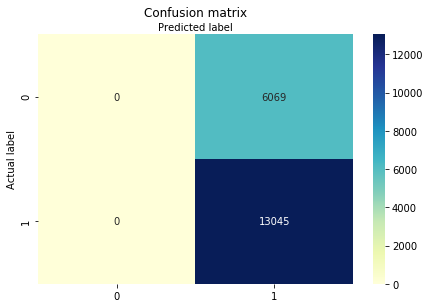

In [53]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred))

Since we're more interesting in getting a value between 0 and 1 for a predicted probability of winning, I then went about doing so with the predict_proba function.

In [54]:
clf = LogisticRegression(random_state = 42, max_iter=1000)
clf.fit(X_train,y_train)
# classes = model.predict(X_test)
# probs = model.predict_proba(X_test)
# print(np.bincount(classes))

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [55]:
clf.predict_proba(X_test)

array([[0.34100628, 0.65899372],
       [0.34100628, 0.65899372],
       [0.34100628, 0.65899372],
       ...,
       [0.34091422, 0.65908578],
       [0.34091422, 0.65908578],
       [0.34091422, 0.65908578]])

From this output, it still seems quite skewed that the home team wins with about 66% of the time in essentially every row. Not sure what the fix for this would be, but it seems that for both predict and predict_proba, the model simply assumes the home team wins.

In [57]:
sub = pd.read_csv('sample_submission.csv')
sub['target'] = clf.predict_proba(X_test)[:,1]
sub['game_id'] = X_test.iloc[:,0]
sub['game_id'] = sub['game_id'].ffill()
# for i in range(1, len(sub)):
#     #print(sub['game_id'][i])
#     if sub['game_id'][i] == 'NaN':
#         print('hi')
#         sub['game_id'][i] = sub['game_id'][i - 1]
print(sub)
sub.to_csv('submission.csv',index=False)  

         target        game_id
0      0.658994  19_01_04_2_13
1      0.658994  19_01_04_2_13
2      0.658994  19_01_04_2_13
3      0.658994  19_01_04_2_13
4      0.658994  19_01_04_2_13
...         ...            ...
19109  0.659086  19_01_04_7_14
19110  0.659086  19_01_04_7_14
19111  0.659086  19_01_04_7_14
19112  0.659086  19_01_04_7_14
19113  0.659086  19_01_04_7_14

[19114 rows x 2 columns]
